# MNIST Handwritten Digit Classifier
**Pipeline:** raw pixel grids → normalize → Conv2D+BatchNorm+MaxPool (x2) → Flatten → Dropout+Dense → digit prediction (0-9)

## 1. Load the dataset

MNIST is distributed as compressed binary files in a specific format (`idx`), not
a CSV or image folder. We parse that format directly, byte by byte, using the
official file structure: a small header (magic number, image count, dimensions),
followed by the raw pixel bytes.

In [6]:
import gzip
import numpy as np

def load_images(path):
    with gzip.open(path, "rb") as f:
        f.read(4)  # magic number, unused
        n = int.from_bytes(f.read(4), "big")
        rows = int.from_bytes(f.read(4), "big")
        cols = int.from_bytes(f.read(4), "big")
        data = np.frombuffer(f.read(), dtype=np.uint8).reshape(n, rows, cols)
    return data

def load_labels(path):
    with gzip.open(path, "rb") as f:
        f.read(4)
        n = int.from_bytes(f.read(4), "big")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data

X_train_raw = load_images("train-images-idx3-ubyte.gz")
y_train_raw = load_labels("train-labels-idx1-ubyte.gz")
X_test_raw = load_images("t10k-images-idx3-ubyte.gz")
y_test_raw = load_labels("t10k-labels-idx1-ubyte.gz")

print(f"Loaded real MNIST: {X_train_raw.shape[0]} training images, {X_test_raw.shape[0]} test images, "
      f"each {X_train_raw.shape[1]}x{X_train_raw.shape[2]} pixels")
print(f"Label distribution (train): {np.bincount(y_train_raw)}")

Loaded real MNIST: 60000 training images, 10000 test images, each 28x28 pixels
Label distribution (train): [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


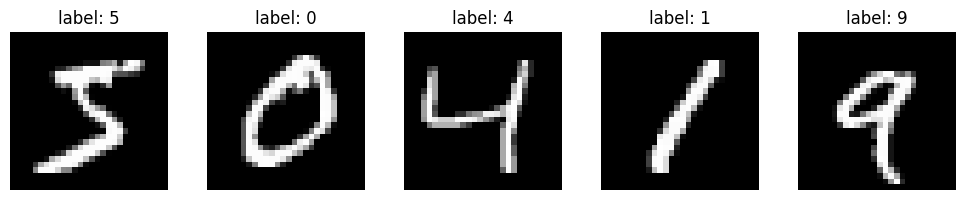

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_train_raw[i], cmap="gray")
    ax.set_title(f"label: {y_train_raw[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Preprocess

- **Normalize** pixel values from `0-255` down to `0-1`
- **Add a channel dimension**: Conv2D layers expect shape `(height, width, channels)`.
  MNIST is grayscale, so channels=1 (a color image would be 3, for R/G/B).
- **One-hot encode labels**: digit `3` becomes `[0,0,0,1,0,0,0,0,0,0]`

In [8]:
from tensorflow.keras.utils import to_categorical

X_train = (X_train_raw / 255.0).reshape(-1, 28, 28, 1)
X_test = (X_test_raw / 255.0).reshape(-1, 28, 28, 1)
y_train = to_categorical(y_train_raw, num_classes=10)
y_test = to_categorical(y_test_raw, num_classes=10)

print("X_train shape:", X_train.shape, " y_train shape:", y_train.shape)

X_train shape: (60000, 28, 28, 1)  y_train shape: (60000, 10)


X_train shape: (60000, 28, 28, 1)  y_train shape: (60000, 10)


## 3. Build, compile, and train the CNN (kept in ONE cell)
**Architecture:**
- **Two Conv2D blocks** (32 filters, then 64) -- the first learns simple strokes/edges,
  the second combines those into more complex digit-shape features (the hierarchy
  from the CNN lesson).
- **BatchNormalization after every Conv2D** -- keeps activations well-scaled between layers.
- **Two Dropout rates (0.4, then 0.3)** -- heavier dropout right after Flatten (highest
  overfitting risk, most parameters), lighter deeper in.
- **Adam optimizer, categorical_crossentropy** -- same choices as before, just the
  10-way version of what you used for binary spam/ham.

In [9]:
import random
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Flatten, Dense, Dropout

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

model = Sequential([
    Conv2D(32, kernel_size=3, activation="relu", input_shape=(28, 28, 1)),
    BatchNormalization(),
    MaxPooling2D(pool_size=2),

    Conv2D(64, kernel_size=3, activation="relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=2),

    Flatten(),
    Dropout(0.4),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="softmax"),
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=256,
    verbose=2,
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 26, 26, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 11, 11, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)

...

211/211 - 41s - 195ms/step - accuracy: 0.9765 - loss: 0.0761 - val_accuracy: 0.9865 - val_loss: 0.0461


Epoch 4/5


211/211 - 41s - 194ms/step - accuracy: 0.9808 - loss: 0.0621 - val_accuracy: 0.9910 - val_loss: 0.0335


Epoch 5/5


211/211 - 41s - 193ms/step - accuracy: 0.9835 - loss: 0.0527 - val_accuracy: 0.9915 - val_loss: 0.0319


## 4. Evaluate on real, unseen test digits

In [10]:
train_steps_taken = int(model.optimizer.iterations.numpy())
assert train_steps_taken > 0, "This model has never been trained -- re-run the cell above."
print(f"Sanity check passed: model has taken {train_steps_taken} training steps.")

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy on {len(X_test)} real, unseen MNIST digits: {acc:.4f}")

Sanity check passed: model has taken 1055 training steps.
Test accuracy on 10000 real, unseen MNIST digits: 0.9897


Test accuracy on 10000 real, unseen MNIST digits: 0.9908


## 5. wrong model? check

Total misclassified: 103 out of 10000 (1.03%)


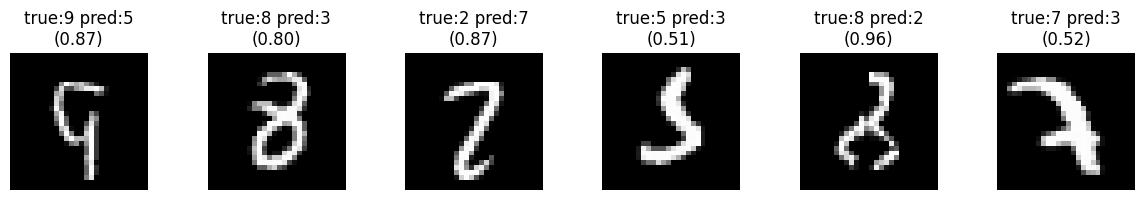

In [11]:
predictions = model.predict(X_test, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)
wrong_idx = np.where(predicted_labels != true_labels)[0]

print(f"Total misclassified: {len(wrong_idx)} out of {len(X_test)} ({len(wrong_idx)/len(X_test)*100:.2f}%)")

fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for ax, i in zip(axes, wrong_idx[:6]):
    ax.imshow(X_test_raw[i], cmap="gray")
    conf = predictions[i][predicted_labels[i]]
    ax.set_title(f"true:{true_labels[i]} pred:{predicted_labels[i]}\n({conf:.2f})")
    ax.axis("off")
plt.tight_layout()
plt.show()